All libraries imported successfully!


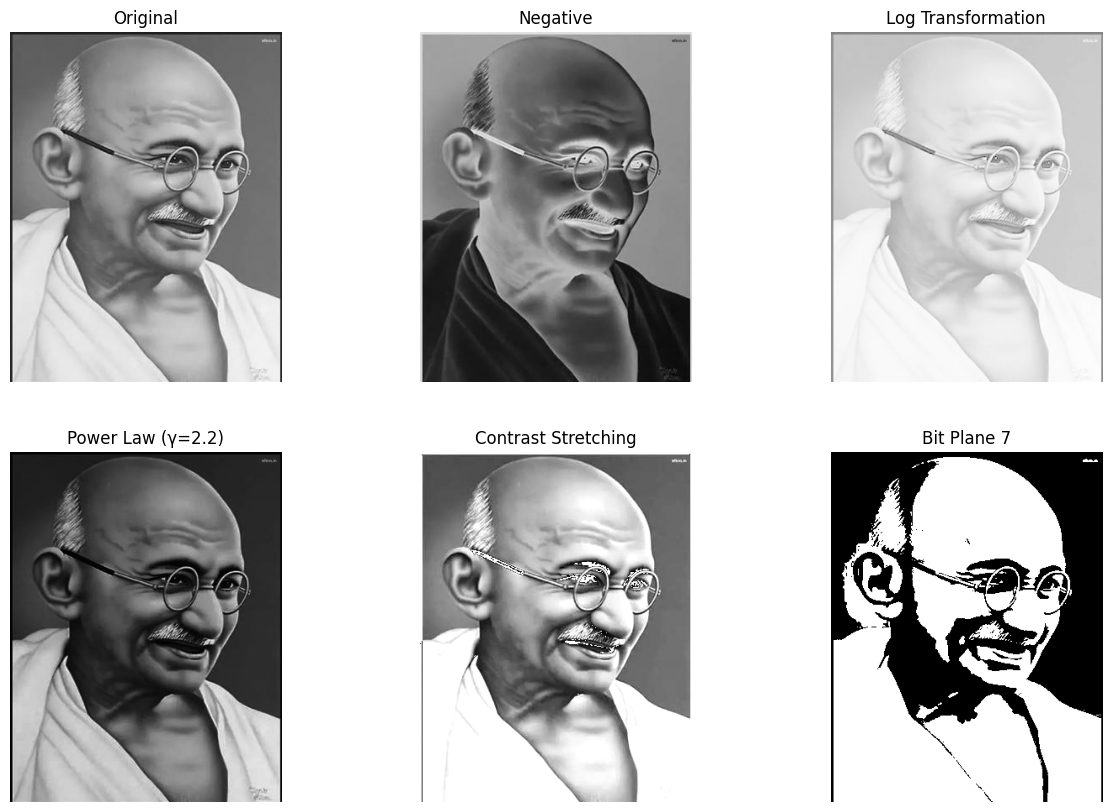

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

print("All libraries imported successfully!")

def exp1_point_processing():
    # Read uploaded image in grayscale
    img = cv2.imread("ht.JPG", 0)

    if img is None:
        print("Image not found!")
        return

    # Negative transformation
    img_negative = 255 - img

    # Log transformation (safe)
    img_float = img.astype(np.float32)
    c = 255 / np.log(1 + np.max(img_float))
    img_log = np.uint8(c * np.log(img_float + 1))

    # Power-law (Gamma) transformation
    gamma = 2.2
    img_power = np.uint8(255 * (img_float / 255) ** gamma)

    # Contrast stretching
    min_val, max_val = 50, 200
    img_stretched = np.uint8(
        np.clip((img - min_val) * (255 / (max_val - min_val)), 0, 255)
    )

    # Bit-plane slicing (MSB)
    bit_plane_7 = ((img >> 7) & 1) * 255

    titles = [
        "Original",
        "Negative",
        "Log Transformation",
        f"Power Law (γ={gamma})",
        "Contrast Stretching",
        "Bit Plane 7"
    ]

    images = [
        img,
        img_negative,
        img_log,
        img_power,
        img_stretched,
        bit_plane_7
    ]

    plt.figure(figsize=(15, 10))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.show()

# Call function
exp1_point_processing()